# **New York City Yellow Taxi Data**

## Objective
In this case study you will be learning exploratory data analysis (EDA) with the help of a dataset on yellow taxi rides in New York City. This will enable you to understand why EDA is an important step in the process of data science and machine learning.

## **Problem Statement**
As an analyst at an upcoming taxi operation in NYC, you are tasked to use the 2023 taxi trip data to uncover insights that could help optimise taxi operations. The goal is to analyse patterns in the data that can inform strategic decisions to improve service efficiency, maximise revenue, and enhance passenger experience.

## Tasks
You need to perform the following steps for successfully completing this assignment:
1. Data Loading
2. Data Cleaning
3. Exploratory Analysis: Bivariate and Multivariate
4. Creating Visualisations to Support the Analysis
5. Deriving Insights and Stating Conclusions

---

**NOTE:** The marks given along with headings and sub-headings are cumulative marks for those particular headings/sub-headings.<br>

The actual marks for each task are specified within the tasks themselves.

For example, marks given with heading *2* or sub-heading *2.1* are the cumulative marks, for your reference only. <br>

The marks you will receive for completing tasks are given with the tasks.

Suppose the marks for two tasks are: 3 marks for 2.1.1 and 2 marks for 3.2.2, or
* 2.1.1 [3 marks]
* 3.2.2 [2 marks]

then, you will earn 3 marks for completing task 2.1.1 and 2 marks for completing task 3.2.2.


---

## Data Understanding
The yellow taxi trip records include fields capturing pick-up and drop-off dates/times, pick-up and drop-off locations, trip distances, itemized fares, rate types, payment types, and driver-reported passenger counts.

The data is stored in Parquet format (*.parquet*). The dataset is from 2009 to 2024. However, for this assignment, we will only be using the data from 2023.

The data for each month is present in a different parquet file. You will get twelve files for each of the months in 2023.

The data was collected and provided to the NYC Taxi and Limousine Commission (TLC) by technology providers like vendors and taxi hailing apps. <br>

You can find the link to the TLC trip records page here: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

###  Data Description
You can find the data description here: [Data Dictionary](https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf)

**Trip Records**



|Field Name       |description |
|:----------------|:-----------|
| VendorID | A code indicating the TPEP provider that provided the record. <br> 1= Creative Mobile Technologies, LLC; <br> 2= VeriFone Inc. |
| tpep_pickup_datetime | The date and time when the meter was engaged.  |
| tpep_dropoff_datetime | The date and time when the meter was disengaged.   |
| Passenger_count | The number of passengers in the vehicle. <br> This is a driver-entered value. |
| Trip_distance | The elapsed trip distance in miles reported by the taximeter. |
| PULocationID | TLC Taxi Zone in which the taximeter was engaged |
| DOLocationID | TLC Taxi Zone in which the taximeter was disengaged |
|RateCodeID |The final rate code in effect at the end of the trip.<br> 1 = Standard rate <br> 2 = JFK <br> 3 = Newark <br>4 = Nassau or Westchester <br>5 = Negotiated fare <br>6 = Group ride |
|Store_and_fwd_flag |This flag indicates whether the trip record was held in vehicle memory before sending to the vendor, aka “store and forward,” because the vehicle did not have a connection to the server.  <br>Y= store and forward trip <br>N= not a store and forward trip |
|Payment_type| A numeric code signifying how the passenger paid for the trip. <br> 1 = Credit card <br>2 = Cash <br>3 = No charge <br>4 = Dispute <br>5 = Unknown <br>6 = Voided trip |
|Fare_amount| The time-and-distance fare calculated by the meter. <br>Extra Miscellaneous extras and surcharges.  Currently, this only includes the 0.50 and 1 USD rush hour and overnight charges. |
|MTA_tax |0.50 USD MTA tax that is automatically triggered based on the metered rate in use. |
|Improvement_surcharge | 0.30 USD improvement surcharge assessed trips at the flag drop. The improvement surcharge began being levied in 2015. |
|Tip_amount |Tip amount – This field is automatically populated for credit card tips. Cash tips are not included. |
| Tolls_amount | Total amount of all tolls paid in trip.  |
| total_amount | The total amount charged to passengers. Does not include cash tips. |
|Congestion_Surcharge |Total amount collected in trip for NYS congestion surcharge. |
| Airport_fee | 1.25 USD for pick up only at LaGuardia and John F. Kennedy Airports|

Although the amounts of extra charges and taxes applied are specified in the data dictionary, you will see that some cases have different values of these charges in the actual data.

**Taxi Zones**

Each of the trip records contains a field corresponding to the location of the pickup or drop-off of the trip, populated by numbers ranging from 1-263.

These numbers correspond to taxi zones, which may be downloaded as a table or map/shapefile and matched to the trip records using a join.

This is covered in more detail in later sections.

---

## **1** Data Preparation

<font color = red>[5 marks]</font> <br>

### Import Libraries

In [7]:
# Import warnings
import warnings
warnings.filterwarnings('ignore')

In [1]:
# Import the libraries you will be using for analysis
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [9]:
# Recommended versions
# numpy version: 1.26.4
# pandas version: 2.2.2
# matplotlib version: 3.10.0
# seaborn version: 0.13.2

# Check versions
print("numpy version:", np.__version__)
print("pandas version:", pd.__version__)
print("matplotlib version:", plt.matplotlib.__version__)
print("seaborn version:", sns.__version__)

numpy version: 2.2.6
pandas version: 2.3.3
matplotlib version: 3.10.8
seaborn version: 0.13.2


### **1.1** Load the dataset
<font color = red>[5 marks]</font> <br>

You will see twelve files, one for each month.

To read parquet files with Pandas, you have to follow a similar syntax as that for CSV files.

`df = pd.read_parquet('file.parquet')`

In [2]:
# Try loading one file
PATH = 'C:/Users/Rahul Jeyaraj/projects/APAGAI - Assignment - EDA/Starter Notebook - EDA NYC Taxi/trip_records/'
df = pd.read_parquet(PATH + '2023-1.parquet')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3041714 entries, 0 to 3066765
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee            floa

How many rows are there? Do you think handling such a large number of rows is computationally feasible when we have to combine the data for all twelve months into one?

To handle this, we need to sample a fraction of data from each of the files. How to go about that? Think of a way to select only some portion of the data from each month's file that accurately represents the trends.

#### Sampling the Data
> One way is to take a small percentage of entries for pickup in every hour of a date. So, for all the days in a month, we can iterate through the hours and select 5% values randomly from those. Use `tpep_pickup_datetime` for this. Separate date and hour from the datetime values and then for each date, select some fraction of trips for each of the 24 hours.

To sample data, you can use the `sample()` method. Follow this syntax:

```Python
# sampled_data is an empty DF to keep appending sampled data of each hour
# hour_data is the DF of entries for an hour 'X' on a date 'Y'

sample = hour_data.sample(frac = 0.05, random_state = 42)
# sample 0.05 of the hour_data
# random_state is just a seed for sampling, you can define it yourself

sampled_data = pd.concat([sampled_data, sample]) # adding data for this hour to the DF
```

This *sampled_data* will contain 5% values selected at random from each hour.

Note that the code given above is only the part that will be used for sampling and not the complete code required for sampling and combining the data files.

Keep in mind that you sample by date AND hour, not just hour. (Why?)

---

**1.1.1** <font color = red>[5 marks]</font> <br>
Figure out how to sample and combine the files.

**Note:** It is not mandatory to use the method specified above. While sampling, you only need to make sure that your sampled data represents the overall data of all the months accurately.

In [ ]:
# Sample the data
# It is recommmended to not load all the files at once to avoid memory overload

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [12]:
# Take a small percentage of entries from each hour of every date.
# Iterating through the monthly data:
#   read a month file -> day -> hour: append sampled data -> move to next hour -> move to next day after 24 hours -> move to next month file
# Create a single dataframe for the year combining all the monthly data

# Select the folder having data files
import os

# Select the folder having data files
os.chdir(PATH)

# Create a list of all the twelve files to read
file_list = os.listdir()

# initialise an empty dataframe
df = pd.DataFrame()


# iterate through the list of files and sample one by one:
for file_name in file_list:
    try:
        # file path for the current file
        file_path = os.path.join(os.getcwd(), file_name)

        # Reading the current file
        trip_record_df = pd.read_parquet(file_path)
        trip_record_df['date'] = trip_record_df['tpep_pickup_datetime'].dt.date
        trip_record_df['hour'] = trip_record_df['tpep_pickup_datetime'].dt.hour

        # We will store the sampled data for the current date in this df by appending the sampled data from each hour to this
        # After completing iteration through each date, we will append this data to the final dataframe.
        sampled_data = pd.DataFrame()

        # Loop through dates and then loop through every hour of each date
        for date in trip_record_df['date'].unique():
            df_date = trip_record_df[trip_record_df['date'] == date]

            # Iterate through each hour of the selected date
            for hour in range(24):
                df_hour = df_date[df_date['hour'] == hour]
                if len(df_hour) == 0:
                    continue

                # Sample 5% of the hourly data randomly
                sample = df_hour.sample(frac = 0.05, random_state = 42)

                # add data of this hour to the dataframe
                sampled_data = pd.concat([sampled_data, sample])

        # Drop temporary columns
        sampled_data = sampled_data.drop(columns=['date', 'hour'])

        # Concatenate the sampled data of all the dates to a single dataframe
        df = pd.concat([df, sampled_data])
        print(f"  Sampled: {len(sampled_data):,} rows | Total so far: {len(df):,}")

    except Exception as e:
        print(f"Error reading file {file_name}: {e}")

  Sampled: 152,087 rows | Total so far: 152,087
  Sampled: 174,255 rows | Total so far: 326,342
  Sampled: 165,133 rows | Total so far: 491,475
  Sampled: 166,709 rows | Total so far: 658,184
  Sampled: 168,696 rows | Total so far: 826,880
  Sampled: 163,786 rows | Total so far: 990,666
  Sampled: 139,641 rows | Total so far: 1,130,307
  Sampled: 144,458 rows | Total so far: 1,274,765
  Sampled: 162,910 rows | Total so far: 1,437,675
  Sampled: 174,068 rows | Total so far: 1,611,743
  Sampled: 143,782 rows | Total so far: 1,755,525
  Sampled: 140,875 rows | Total so far: 1,896,400
  Sampled: 99,662 rows | Total so far: 1,996,062
  Sampled: 94,927 rows | Total so far: 2,090,989


After combining the data files into one DataFrame, convert the new DataFrame to a CSV or parquet file and store it to use directly.

Ideally, you can try keeping the total entries to around 250,000 to 300,000.

In [8]:
# Store the df in csv/parquet
df.to_parquet(PATH + 'nyc_taxi_sampled_2023.parquet', index=False)
print(f"Saved sampled data: {len(df):,} rows")

Saved sampled data: 2,090,989 rows


## **2** Data Cleaning
<font color = red>[30 marks]</font> <br>

Now we can load the new data directly.

In [21]:
# Load the new data file
df = pd.read_parquet(PATH + 'nyc_taxi_sampled_2023.parquet')


In [10]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,Airport_fee
0,2,2023-01-01 00:07:18,2023-01-01 00:23:15,1.0,7.74,1.0,N,138,256,2,32.40,6.0,0.5,0.00,0.0,1.0,41.15,0.0,1.25,NaN
1,2,2023-01-01 00:16:41,2023-01-01 00:21:46,2.0,1.24,1.0,N,161,237,1,7.90,1.0,0.5,2.58,0.0,1.0,15.48,2.5,0.00,NaN
2,2,2023-01-01 00:14:03,2023-01-01 00:24:36,3.0,1.44,1.0,N,237,141,2,11.40,1.0,0.5,0.00,0.0,1.0,16.40,2.5,0.00,NaN
3,2,2023-01-01 00:24:30,2023-01-01 00:29:55,1.0,0.54,1.0,N,143,142,2,6.50,1.0,0.5,0.00,0.0,1.0,11.50,2.5,0.00,NaN
4,2,2023-01-01 00:43:00,2023-01-01 01:01:00,NaN,19.24,NaN,None,66,107,0,25.64,0.0,0.5,5.93,0.0,1.0,35.57,NaN,NaN,NaN


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2090989 entries, 0 to 2090988
Data columns (total 20 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee           

#### **2.1** Fixing Columns
<font color = red>[10 marks]</font> <br>

Fix/drop any columns as you seem necessary in the below sections

**2.1.1** <font color = red>[2 marks]</font> <br>

Fix the index and drop unnecessary columns

In [22]:
# Fix the index and drop any columns that are not needed
# Reset index to ensure clean sequential indexing
df = df.reset_index(drop=True)

# Drop 'store_and_fwd_flag' as it is not useful for our analysis
df = df.drop(columns=['store_and_fwd_flag'], errors='ignore')

print(f"Shape after dropping unnecessary columns: {df.shape}")
df.head()


Shape after dropping unnecessary columns: (2090989, 19)


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,Airport_fee
0,2,2023-01-01 00:07:18,2023-01-01 00:23:15,1.0,7.74,1.0,138,256,2,32.40,6.0,0.5,0.00,0.0,1.0,41.15,0.0,1.25,NaN
1,2,2023-01-01 00:16:41,2023-01-01 00:21:46,2.0,1.24,1.0,161,237,1,7.90,1.0,0.5,2.58,0.0,1.0,15.48,2.5,0.00,NaN
2,2,2023-01-01 00:14:03,2023-01-01 00:24:36,3.0,1.44,1.0,237,141,2,11.40,1.0,0.5,0.00,0.0,1.0,16.40,2.5,0.00,NaN
3,2,2023-01-01 00:24:30,2023-01-01 00:29:55,1.0,0.54,1.0,143,142,2,6.50,1.0,0.5,0.00,0.0,1.0,11.50,2.5,0.00,NaN
4,2,2023-01-01 00:43:00,2023-01-01 01:01:00,NaN,19.24,NaN,66,107,0,25.64,0.0,0.5,5.93,0.0,1.0,35.57,NaN,NaN,NaN


**2.1.2** <font color = red>[3 marks]</font> <br>
There are two airport fee columns. This is possibly an error in naming columns. Let's see whether these can be combined into a single column.

In [23]:
# Combine the two airport fee columns
# Fill NaN with 0 and combine them by taking the sum (since one should be 0 or NaN)
df['airport_fee'] = df['airport_fee'].fillna(0) + df['Airport_fee'].fillna(0)
df = df.drop(columns=['Airport_fee'])
print(f"\nairport_fee value counts:\n{df['airport_fee'].value_counts()}")


airport_fee value counts:
airport_fee
 0.00    1913614
 1.75     133604
 1.25      43753
-1.75         13
-1.25          4
 1.00          1
Name: count, dtype: int64


**2.1.3** <font color = red>[5 marks]</font> <br>
Fix columns with negative (monetary) values

In [24]:
# check where values of fare amount are negative
negative_fares = df[df['fare_amount'] < 0]
print(f"Number of records with negative fare_amount: {len(negative_fares)}")

Number of records with negative fare_amount: 0


Did you notice something different in the `RatecodeID` column for above records?

In [25]:
# Analyse RatecodeID for the negative fare amounts
if len(negative_fares) > 0:
    print("RatecodeID distribution for negative fare records:")
    print(negative_fares['RatecodeID'].value_counts())
else:
    print("No negative fare_amount records found in our sampled data.")
    print("This is expected — sampling 5% randomly may have excluded such rare anomalies.")
    print("\nFor reference, overall RatecodeID distribution:")
    print(df['RatecodeID'].value_counts())
    print("\nNote: RatecodeID = 99 is undefined per data dictionary — flagged for outlier handling")

No negative fare_amount records found in our sampled data.
This is expected — sampling 5% randomly may have excluded such rare anomalies.

For reference, overall RatecodeID distribution:
RatecodeID
1.0     1906637
2.0       79042
99.0      11522
5.0       11351
3.0        6736
4.0        4108
6.0           3
Name: count, dtype: int64

Note: RatecodeID = 99 is undefined per data dictionary — flagged for outlier handling


In [26]:
# Find which columns have negative values
numeric_cols = df.select_dtypes(include=[np.number]).columns
print("\nColumns with negative values:")
for col in numeric_cols:
    neg_count = (df[col] < 0).sum()
    if neg_count > 0:
        print(f"{col}: {neg_count}")


Columns with negative values:
extra: 3
mta_tax: 86
improvement_surcharge: 91
total_amount: 91
congestion_surcharge: 65
airport_fee: 17


In [27]:
# fix these negative values
for col in numeric_cols:
    neg_count = (df[col] < 0).sum()
    if neg_count > 0:
        df[col] = df[col].abs()
        print(f"Fixed {neg_count} negative values in '{col}'")


Fixed 3 negative values in 'extra'
Fixed 86 negative values in 'mta_tax'
Fixed 91 negative values in 'improvement_surcharge'
Fixed 91 negative values in 'total_amount'
Fixed 65 negative values in 'congestion_surcharge'
Fixed 17 negative values in 'airport_fee'


### **2.2** Handling Missing Values
<font color = red>[10 marks]</font> <br>

**2.2.1**  <font color = red>[2 marks]</font> <br>
Find the proportion of missing values in each column




In [31]:
# Find the proportion of missing values in each column
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print("Columns with missing values:\n")
print(missing_df.to_string())
print(f"\nTotal rows: {len(df):,}")


Columns with missing values:

                      Missing Count  Missing %
passenger_count               71590   3.423739
RatecodeID                    71590   3.423739
congestion_surcharge          71590   3.423739

Total rows: 2,090,989


**2.2.2**  <font color = red>[3 marks]</font> <br>
Handling missing values in `passenger_count`

In [35]:
# Display the rows with null values
# Impute NaN values in 'passenger_count'
print(f"Null values in 'passenger_count': {df['passenger_count'].isnull().sum()}")
print(f"Zero values in 'passenger_count': {(df['passenger_count'] == 0).sum()}")

# Impute NaN values in 'passenger_count' with mode
mode_passenger_count = df['passenger_count'].mode()[0]
print(f"Mode of 'passenger_count': {mode_passenger_count}")
df['passenger_count'] = df['passenger_count'].fillna(mode_passenger_count)

# Handle any zero values in 'passenger_count' (assuming 0 passengers is not valid for a taxi trip)
df.loc[df['passenger_count'] == 0, 'passenger_count'] = mode_passenger_count

print(f"\nAfter imputation:")
print(f"\tNull values in 'passenger_count': {df['passenger_count'].isnull().sum()}")
print(f"\tZero values in 'passenger_count': {(df['passenger_count'] == 0).sum()}")
print(f"\nPassenger_count distribution:")
print(df['passenger_count'].value_counts().sort_index())

Null values in 'passenger_count': 0
Zero values in 'passenger_count': 0
Mode of 'passenger_count': 1.0

After imputation:
	Null values in 'passenger_count': 0
	Zero values in 'passenger_count': 0

Passenger_count distribution:
passenger_count
1.0    1623288
2.0     305678
3.0      75866
4.0      42430
5.0      26195
6.0      17510
7.0          5
8.0         12
9.0          5
Name: count, dtype: int64


Did you find zeroes in passenger_count? Handle these.

**2.2.3**  <font color = red>[2 marks]</font> <br>
Handle missing values in `RatecodeID`

In [37]:
# Fix missing values in 'RatecodeID'
print(f"Null values in RatecodeID: {df['RatecodeID'].isnull().sum()}")
print(f"RatecodeID value counts before fix:")
print(df['RatecodeID'].value_counts().sort_index())

# Replace RatecodeID = 99 with NaN (these are error codes), then fill with mode
df.loc[df['RatecodeID'] == 99, 'RatecodeID'] = np.nan

mode_ratecodeid = df['RatecodeID'].mode()[0]
df['RatecodeID'] = df['RatecodeID'].fillna(mode_ratecodeid)

print(f"\n RatecodeID value counts after fix:")
print(df['RatecodeID'].value_counts().sort_index())

Null values in RatecodeID: 71590
RatecodeID value counts before fix:
RatecodeID
1.0     1906637
2.0       79042
3.0        6736
4.0        4108
5.0       11351
6.0           3
99.0      11522
Name: count, dtype: int64

 RatecodeID value counts after fix:
RatecodeID
1.0    1989749
2.0      79042
3.0       6736
4.0       4108
5.0      11351
6.0          3
Name: count, dtype: int64


**2.2.4**  <font color = red>[3 marks]</font> <br>
Impute NaN in `congestion_surcharge`

In [38]:
# handle null values in congestion_surcharge
print(f"Null values in congestion_surcharge: {df['congestion_surcharge'].isnull().sum()}")
print(f"Congestion surcharge value counts before fix:")
print(df['congestion_surcharge'].value_counts().sort_index())

# Impute NaN values in 'congestion_surcharge' with 0 (assuming no surcharge if not specified)
df['congestion_surcharge'] = df['congestion_surcharge'].fillna(0)

print(f"\nCongestion surcharge value counts after fix:")
print(df['congestion_surcharge'].value_counts().sort_index())


Null values in congestion_surcharge: 71590
Congestion surcharge value counts before fix:
congestion_surcharge
0.0     155211
0.5          1
2.5    1864187
Name: count, dtype: int64

Congestion surcharge value counts after fix:
congestion_surcharge
0.0     226801
0.5          1
2.5    1864187
Name: count, dtype: int64


Are there missing values in other columns? Did you find NaN values in some other set of columns? Handle those missing values below.

In [39]:
# Handle any remaining missing values
remaining_missing = df.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0]

if len(remaining_missing) > 0:
    print("\nRemaining columns with missing values:")
    print(remaining_missing)

    #Fill remaining missing values with 0 (assuming missing means no charge for these columns)
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    for col in remaining_missing.index:
        if col in numeric_cols:
            df[col] = df[col].fillna(0)
            print(f"Filled missing values in '{col}' with 0")
else:
    print("\nNo remaining missing values.")

# Final check for missing values
print("\nFinal check for missing values:")
print(df.isnull().sum())


No remaining missing values.

Final check for missing values:
VendorID                 0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
RatecodeID               0
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
extra                    0
mta_tax                  0
tip_amount               0
tolls_amount             0
improvement_surcharge    0
total_amount             0
congestion_surcharge     0
airport_fee              0
dtype: int64


### **2.3** Handling Outliers
<font color = red>[10 marks]</font> <br>

Before we start fixing outliers, let's perform outlier analysis.

In [45]:
# Describe the data and check if there are any potential outliers present
# Check for potential out of place values in various columns

# All numeric columns
all_numeric = df.select_dtypes(include='number').columns.tolist()

# Then exclude the ones that are actually categorical
categorical_numeric = ['VendorID', 'RatecodeID', 'PULocationID', 
                       'DOLocationID', 'payment_type']
desc_cols = [c for c in all_numeric if c not in categorical_numeric]

print("Statistical Summary of Key Columns:\n")
print(df[desc_cols].describe().round(2).to_string())

print("\nPotential Outlier Indicators:\n")
print(f"trip_distance: max = {df['trip_distance'].max():.2f} miles")
print(f"fare_amount: max = ${df['fare_amount'].max():.2f}")
print(f"tip_amount: max = ${df['tip_amount'].max():.2f}")
print(f"tolls_amount: max = ${df['tolls_amount'].max():.2f}")
print(f"total_amount: max = ${df['total_amount'].max():.2f}")
print(f"passenger_count: max = {df['passenger_count'].max()}")
print(f"\ntrip_distance == 0: {(df['trip_distance'] == 0).sum()} trips")
print(f"fare_amount == 0: {(df['fare_amount'] == 0).sum()} trips")

Statistical Summary of Key Columns:

       passenger_count  trip_distance  fare_amount       extra     mta_tax  tip_amount  tolls_amount  improvement_surcharge  total_amount  congestion_surcharge  airport_fee
count       2090989.00     2090989.00   2090989.00  2090989.00  2090989.00  2090989.00    2090989.00             2090989.00    2090989.00            2090989.00   2090989.00
mean              1.37           3.86        19.91        1.59        0.50        3.55          0.60                   1.00         28.97                  2.23         0.14
std               0.86         126.83       100.66        1.83        0.05        4.06          2.19                   0.03        101.58                  0.78         0.46
min               1.00           0.00         0.00        0.00        0.00        0.00          0.00                   0.00          0.00                  0.00         0.00
25%               1.00           1.05         9.30        0.00        0.50        1.00          0.

**2.3.1**  <font color = red>[10 marks]</font> <br>
Based on the above analysis, it seems that some of the outliers are present due to errors in registering the trips. Fix the outliers.

Some points you can look for:
- Entries where `trip_distance` is nearly 0 and `fare_amount` is more than 300
- Entries where `trip_distance` and `fare_amount` are 0 but the pickup and dropoff zones are different (both distance and fare should not be zero for different zones)
- Entries where `trip_distance` is more than 250  miles.
- Entries where `payment_type` is 0 (there is no payment_type 0 defined in the data dictionary)

These are just some suggestions. You can handle outliers in any way you wish, using the insights from above outlier analysis.

How will you fix each of these values? Which ones will you drop and which ones will you replace?

First, let us remove 7+ passenger counts as there are very less instances.

In [46]:
# remove passenger_count > 6
print(f"\nRecords with passenger_count > 6: {(df['passenger_count'] > 6).sum()}")
print(f"Shape before: {df.shape}")
df = df[df['passenger_count'] <= 6]
df = df.reset_index(drop=True)
print(f"Shape after: {df.shape}")


Records with passenger_count > 6: 22
Shape before: (2090989, 18)
Shape after: (2090967, 18)


In [ ]:
# Continue with outlier handling
print(f"Shape before outlier removal: {df.shape}")

# Trip_distance nearly 0 but fare_amount > 300 (error entries)
mask = (df['trip_distance'] < 0.1) & (df['fare_amount'] > 300)
print(f"trip_distance~0 but fare>300: {mask.sum()}")
df = df[~mask]

# Both trip_distance AND fare_amount are 0 but zones are different (trip didn't happen)
mask = (df['trip_distance'] == 0) & (df['fare_amount'] == 0) & (df['PULocationID'] != df['DOLocationID'])
print(f"distance=0, fare=0, different zones: {mask.sum()}")
df = df[~mask]

# trip_distance > 250 miles (unrealistic for NYC taxi)
mask = df['trip_distance'] > 250
print(f"trip_distance > 250 miles: {mask.sum()}")
df = df[~mask]

# Payment_type = 0 (undefined in data dictionary)
mask = df['payment_type'] == 0
print(f"payment_type = 0: {mask.sum()}")
df = df[~mask]

# Fare_amount > 300 
mask = df['fare_amount'] > 300
print(f"fare_amount > 300: {mask.sum()}")
df = df[~mask]

# Total_amount > 300 (consistent with fare_amount cap)
mask = df['total_amount'] > 300
print(f"total_amount > 300: {mask.sum()}")
df = df[~mask]

# Drop zero fare trips where payment was Cash or Credit card (should have a fare)
mask = (df['fare_amount'] == 0) & (df['payment_type'].isin([1, 2]))
print(f"Zero fare with Cash/Credit payment: {mask.sum()}")
df = df[~mask]

# Create trip duration column
df['trip_duration'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60
mask = (df['trip_duration'] <= 0) | (df['trip_duration'] > 180)
print(f"Trips with duration <= 0 min: {(df['trip_duration'] <= 0).sum()}")
print(f"Trips with duration > 180 min: {(df['trip_duration'] > 180).sum()}")
print(f"Total removed by duration filter: {mask.sum()}")
df = df[~mask]

# Filter trips within 2023 only
mask = (df['tpep_pickup_datetime'].dt.year != 2023) | (df['tpep_dropoff_datetime'].dt.year != 2023)
print(f"Trips outside 2023: {mask.sum()}")
df = df[~mask]

df = df.reset_index(drop=True)
print(f"\nShape after outlier removal: {df.shape}")



Shape before outlier removal: (2090967, 18)
trip_distance~0 but fare>300: 36
distance=0, fare=0, different zones: 69
trip_distance > 250 miles: 50
payment_type = 0: 71556
fare_amount > 300: 143
total_amount > 300: 144
Zero fare with Cash/Credit payment: 385
Trips with duration <= 0 min: 755
Trips with duration > 180 min: 1868
Total removed by duration filter: 2623

Trips outside 2023: 24

Shape after outlier removal: (2015937, 19)


In [50]:
# Do any columns need standardising?

df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
df['pickup_day'] = df['tpep_pickup_datetime'].dt.day_name()
df['pickup_month'] = df['tpep_pickup_datetime'].dt.month
df['pickup_month_name'] = df['tpep_pickup_datetime'].dt.month_name()
df['pickup_dayofweek'] = df['tpep_pickup_datetime'].dt.dayofweek
df['isweekend'] = df['pickup_dayofweek'].isin([5, 6]).astype(bool)

#Ensure integer types for ID columns
for col in ['VendorID', 'RatecodeID', 'PULocationID', 'DOLocationID', 'payment_type']:
    if col in df.columns:
        df[col] = df[col].astype(int)

df['passenger_count'] = df['passenger_count'].astype(int)

print("Derived columns added: pickup_hour, pickup_day, pickup_month, pickup_month_name, pickup_dayofweek, is_weekend")
print(f"\nDataFrame shape: {df.shape}")
print(f"\nColumn dtypes:")
print(df.dtypes)


Derived columns added: pickup_hour, pickup_day, pickup_month, pickup_month_name, pickup_dayofweek, is_weekend

DataFrame shape: (2015937, 25)

Column dtypes:
VendorID                          int64
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                   int64
trip_distance                   float64
RatecodeID                        int64
PULocationID                      int64
DOLocationID                      int64
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
airport_fee                     float64
trip_duration                   float64
pickup_hour                       int32
pickup_day                       object
pi

## **3** Exploratory Data Analysis
<font color = red>[90 marks]</font> <br>

In [52]:
df.columns.tolist()

['VendorID',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'RatecodeID',
 'PULocationID',
 'DOLocationID',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge',
 'airport_fee',
 'trip_duration',
 'pickup_hour',
 'pickup_day',
 'pickup_month',
 'pickup_month_name',
 'pickup_dayofweek',
 'isweekend']

#### **3.1** General EDA: Finding Patterns and Trends
<font color = red>[40 marks]</font> <br>

**3.1.1** <font color = red>[3 marks]</font> <br>
Categorise the varaibles into Numerical or Categorical.
* `VendorID`: Categorical (nominal) — just a label for the vendor, 1 or 2
* `tpep_pickup_datetime`: Categorical (temporal) — a timestamp, not a quantity
* `tpep_dropoff_datetime`: Categorical (temporal) — a timestamp, not a quantity
* `passenger_count`: Numerical (discrete) — countable whole numbers
* `trip_distance`: Numerical (continuous) — measurable, can have decimals
* `RatecodeID`: Categorical (nominal) — codes representing rate types, not quantities
* `PULocationID`: Categorical (nominal) — zone codes, not quantities
* `DOLocationID`: Categorical (nominal) — zone codes, not quantities
* `payment_type`: Categorical (nominal) — codes representing payment method
* `pickup_hour`: Categorical (ordinal) — 0-23, has order but not a true quantity
* `trip_duration`: Numerical (continuous) — measured in minutes, can have decimals


The following monetary parameters belong in the same category, is it categorical or numerical?


* `fare_amount`
* `extra`
* `mta_tax`
* `tip_amount`
* `tolls_amount`
* `improvement_surcharge`
* `total_amount`
* `congestion_surcharge`
* `airport_fee`

These are all measured quantities in USD that can take any decimal value — 
making them **continuous numerical variables**.

##### Temporal Analysis

**3.1.2** <font color = red>[5 marks]</font> <br>
Analyse the distribution of taxi pickups by hours, days of the week, and months.

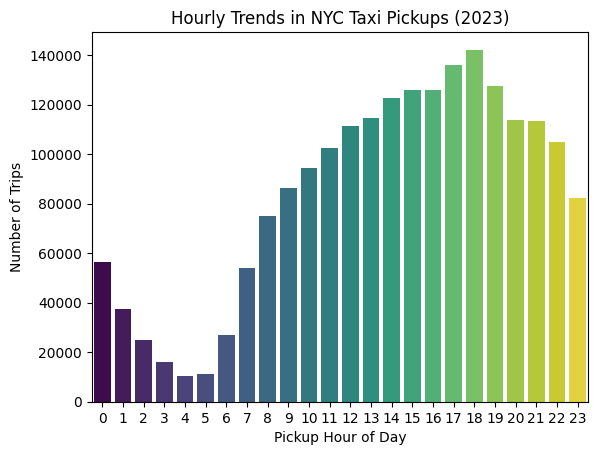

In [56]:
# Find and show the hourly trends in taxi pickups
hourly_pickups = df.groupby('pickup_hour').size().reset_index(name='num_trips')

sns.barplot(x='pickup_hour', y='num_trips', data=hourly_pickups, 
            palette='viridis', hue='pickup_hour', legend=False)
plt.title('Hourly Trends in NYC Taxi Pickups (2023)')
plt.xlabel('Pickup Hour of Day')
plt.ylabel('Number of Trips')
plt.xticks(range(0, 24))
plt.show()

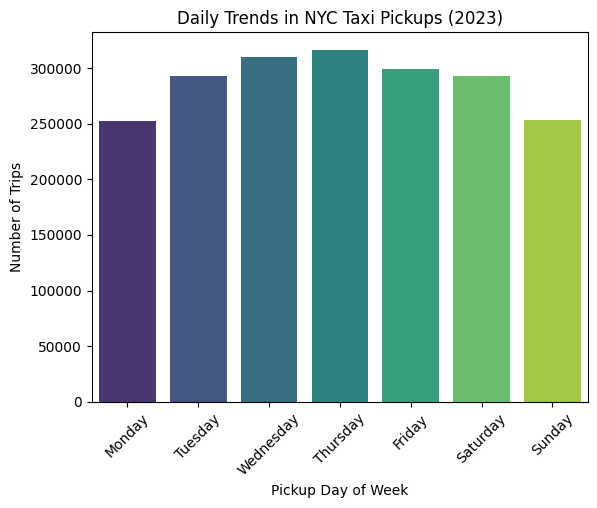

In [67]:
# Find and show the daily trends in taxi pickups (days of the week)
daily_pickups = df.groupby('pickup_day').size().reset_index(name='num_trips')

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_pickups['pickup_day'] = pd.Categorical(daily_pickups['pickup_day'], categories=day_order, ordered=True)
daily_pickups = daily_pickups.sort_values('pickup_day')

sns.barplot(x='pickup_day', y='num_trips', data=daily_pickups,
            palette='viridis', hue='pickup_day', legend=False)
plt.title('Daily Trends in NYC Taxi Pickups (2023)')
plt.xlabel('Pickup Day of Week')
plt.ylabel('Number of Trips')
plt.xticks(rotation=45)
plt.show()


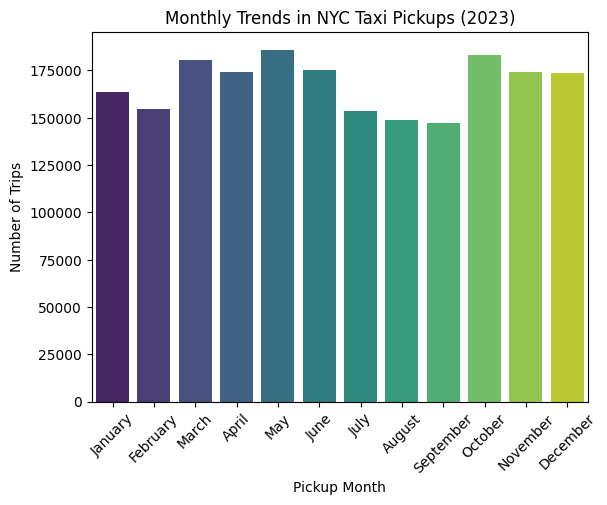

In [66]:
# Show the monthly trends in pickups
monthly_pickups = df.groupby('pickup_month_name').size().reset_index(name='num_trips')
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
monthly_pickups['pickup_month_name'] = pd.Categorical(monthly_pickups['pickup_month_name'], categories=month_order, ordered=True)
monthly_pickups = monthly_pickups.sort_values('pickup_month_name')

sns.barplot(x='pickup_month_name', y='num_trips', data=monthly_pickups,
            palette='viridis', hue='pickup_month_name', legend=False)
plt.title('Monthly Trends in NYC Taxi Pickups (2023)')
plt.xlabel('Pickup Month')
plt.ylabel('Number of Trips')
plt.xticks(rotation=45)
plt.show()

##### Financial Analysis

Take a look at the financial parameters like `fare_amount`, `tip_amount`, `total_amount`, and also `trip_distance`. Do these contain zero/negative values?

In [71]:
# Analyse the above parameters
financial_cols = ['fare_amount', 'tip_amount', 'total_amount', 'trip_distance']

print("Summary statistics for financial and distance parameters:\n")
print(df[financial_cols].describe().round(2).to_string())

print("\nZero/Negative values in financial and distance parameters:")
for col in financial_cols:
    zero_count = (df[col] == 0).sum()
    neg_count = (df[col] < 0).sum()
    print(f"{col}\t: {zero_count} zero values, \t{neg_count} negative values")


Summary statistics for financial and distance parameters:

       fare_amount  tip_amount  total_amount  trip_distance
count   2015937.00  2015937.00    2015937.00     2015937.00
mean         19.69        3.57         28.81           3.44
std          17.81        4.04         22.45           4.49
min           0.00        0.00          0.00           0.00
25%           9.30        1.00         15.96           1.05
50%          13.50        2.86         21.00           1.78
75%          21.90        4.45         30.70           3.37
max         299.00      223.08        300.00         187.35

Zero/Negative values in financial and distance parameters:
fare_amount	: 248 zero values, 	0 negative values
tip_amount	: 450445 zero values, 	0 negative values
total_amount	: 136 zero values, 	0 negative values
trip_distance	: 24311 zero values, 	0 negative values


Do you think it is beneficial to create a copy DataFrame leaving out the zero values from these?


> Original df can be kept for general analysis (trip counts, temporal trends etc.)
> Copy df can be used specifically for financial and distance analysis
>
> If you drop from original:
> - trip counts become wrong
> - hourly/daily trends become inaccurate
> - passenger count analysis loses data
>
> If you use a copy:
> - original df stays intact for non-financial analysis
> - copy df gives accurate financial/distance insights


**3.1.3** <font color = red>[2 marks]</font> <br>
Filter out the zero values from the above columns.

**Note:** The distance might be 0 in cases where pickup and drop is in the same zone. Do you think it is suitable to drop such cases of zero distance?

> No, zero distance trips should not be dropped entirely.
>
> - Pickup and dropoff in the same zone can still be a valid short trip with a legitimate fare
> - We already removed the truly invalid ones in 2.3.1 (distance=0, fare=0, different zones)
> - Remaining zero distance trips are excluded only when distance is directly relevant — using `df_nz`
> - For general analysis like trip counts and revenue, they are kept in `df`


In [73]:
# Create a df with non zero entries for the selected parameters.
df_nz = df[(df['fare_amount'] > 0) & (df['tip_amount'] > 0) &
            (df['total_amount'] > 0) & (df['trip_distance'] > 0)].copy()

print(f"Original df shape: {df.shape}")
print(f"Non-zero df shape: {df_nz.shape}")
print(f"Number of rows removed: {df.shape[0] - df_nz.shape[0]}")
print(f"Number of rows removed percentage: {(df.shape[0] - df_nz.shape[0]) / df.shape[0] * 100:.2f}%")

Original df shape: (2015937, 25)
Non-zero df shape: (1556458, 25)
Number of rows removed: 459479
Number of rows removed percentage: 22.79%


**3.1.4** <font color = red>[3 marks]</font> <br>
Analyse the monthly revenue (`total_amount`) trend

pickup_month_name  total_amount
          January    4455501.23
         February    4215183.07
            March    5072981.25
            April    4993095.89
              May    5435270.92
             June    5115019.45
             July    4444281.30
           August    4337157.53
        September    4424144.57
          October    5450346.86
         November    5073777.19
         December    5061105.47

Highest revenue month: October
Lowest revenue month:  February


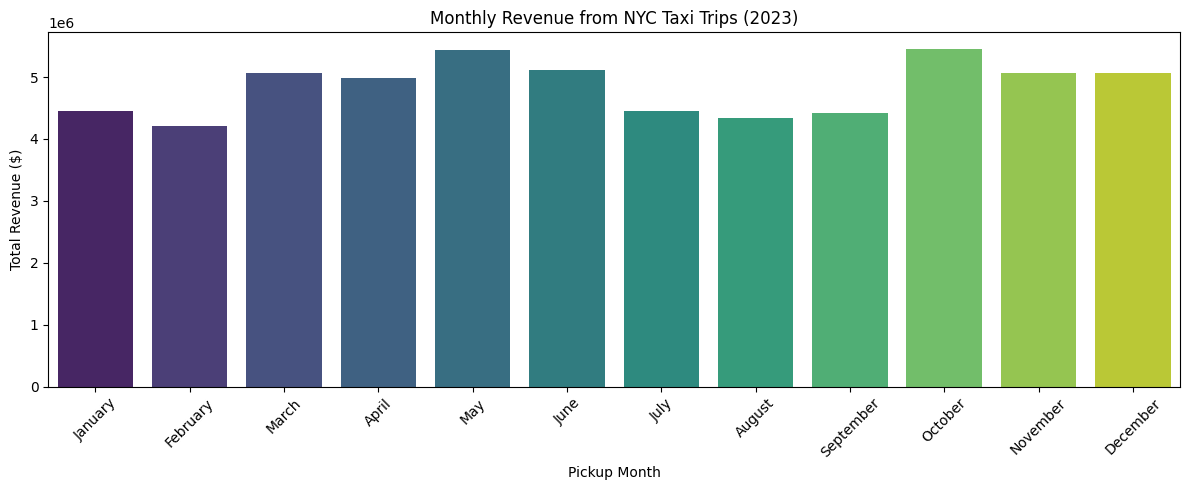

In [77]:
# Group data by month and analyse monthly revenue
monthly_revenue = df.groupby('pickup_month_name')['total_amount'].sum().reset_index()

# Order months correctly
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
monthly_revenue['pickup_month_name'] = pd.Categorical(monthly_revenue['pickup_month_name'], 
                                                       categories=month_order, ordered=True)
monthly_revenue = monthly_revenue.sort_values('pickup_month_name')

# Print summary before plotting
print(monthly_revenue.to_string(index=False))
print(f"\nHighest revenue month: {monthly_revenue.loc[monthly_revenue['total_amount'].idxmax(), 'pickup_month_name']}")
print(f"Lowest revenue month:  {monthly_revenue.loc[monthly_revenue['total_amount'].idxmin(), 'pickup_month_name']}")

plt.figure(figsize=(12, 5))
sns.barplot(x='pickup_month_name', y='total_amount', data=monthly_revenue,
            palette='viridis', hue='pickup_month_name', legend=False)
plt.title('Monthly Revenue from NYC Taxi Trips (2023)')
plt.xlabel('Pickup Month')
plt.ylabel('Total Revenue ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**3.1.5** <font color = red>[3 marks]</font> <br>
Show the proportion of each quarter of the year in the revenue

quarter_label  total_amount  proportion
           Q1   13743665.55   23.664206
           Q2   15543386.26   26.763013
           Q3   13205583.40   22.737722
           Q4   15585229.52   26.835059


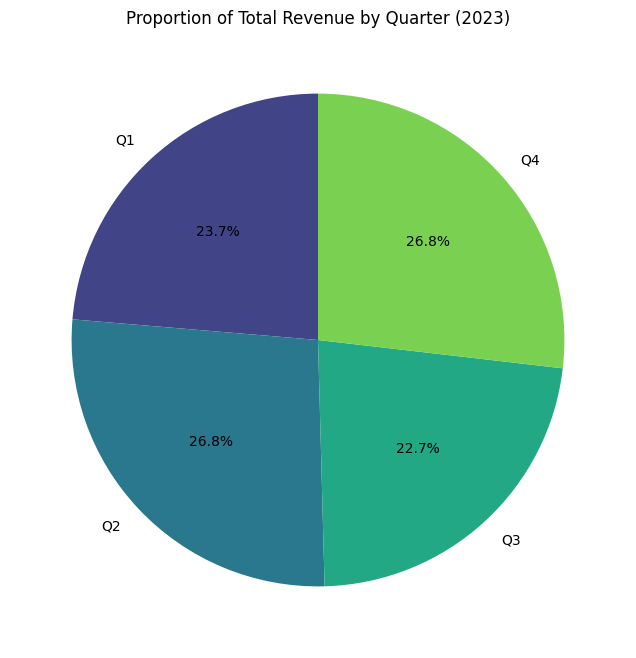

In [82]:
# Calculate proportion of each quarter
df['quarter'] = df['tpep_pickup_datetime'].dt.quarter
quarterly_revenue = df.groupby('quarter')['total_amount'].sum().reset_index()
quarterly_revenue['proportion'] = quarterly_revenue['total_amount'] / quarterly_revenue['total_amount'].sum() * 100
quarterly_revenue['quarter_label'] = [f"Q{q}" for q in quarterly_revenue['quarter']]

# Print summary
print(quarterly_revenue[['quarter_label', 'total_amount', 'proportion']].to_string(index=False))

plt.figure(figsize=(8, 8))
colors = sns.color_palette('viridis', n_colors=4)
plt.pie(quarterly_revenue['proportion'], labels=quarterly_revenue['quarter_label'],
        autopct='%1.1f%%', startangle=90, colors=colors)
plt.title('Proportion of Total Revenue by Quarter (2023)')
plt.show()

**3.1.6** <font color = red>[3 marks]</font> <br>
Visualise the relationship between `trip_distance` and `fare_amount`. Also find the correlation value for these two.

**Hint:** You can leave out the trips with trip_distance = 0

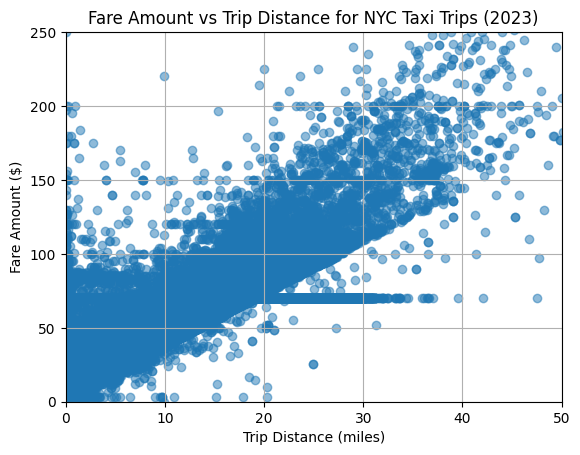

Correlation between trip distance and fare amount: 0.95
There is a strong positive correlation indicating fare increases with distance.


In [86]:
# Show how trip fare is affected by distance
plt.scatter(df_nz['trip_distance'], df_nz['fare_amount'], alpha=0.5)
plt.title('Fare Amount vs Trip Distance for NYC Taxi Trips (2023)')
plt.xlabel('Trip Distance (miles)')
plt.ylabel('Fare Amount ($)')
plt.xlim(0, 50)  # Focus on trips up to 50 miles
plt.ylim(0, 250) # Focus on fares up to $250
plt.grid(True)
plt.show()

corr = df_nz['trip_distance'].corr(df_nz['fare_amount'])
print(f"Correlation between trip distance and fare amount: {corr:.2f}")
print("There is a strong positive correlation indicating fare increases with distance.")


**3.1.7** <font color = red>[5 marks]</font> <br>
Find and visualise the correlation between:
1. `fare_amount` and trip duration (pickup time to dropoff time)
2. `fare_amount` and `passenger_count`
3. `tip_amount` and `trip_distance`

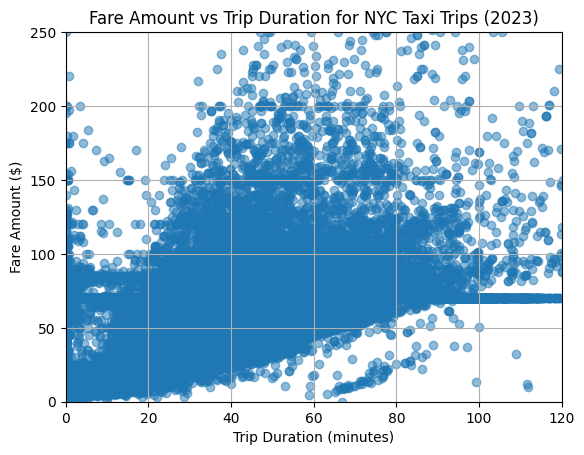

Correlation between trip duration and fare amount: 0.87
There is a positive correlation indicating fare tends to increase with trip duration, but with more variability than distance.


In [91]:
# Show relationship between fare and trip duration
plt.scatter(df_nz['trip_duration'], df_nz['fare_amount'], alpha=0.5)
plt.title('Fare Amount vs Trip Duration for NYC Taxi Trips (2023)')
plt.xlabel('Trip Duration (minutes)')
plt.ylabel('Fare Amount ($)')
plt.xlim(0, 120)  # Focus on trips up to 120 minutes
plt.ylim(0, 250) # Focus on fares up to $250
plt.grid(True)
plt.show()

corr = df_nz['trip_duration'].corr(df_nz['fare_amount'])
print(f"Correlation between trip duration and fare amount: {corr:.2f}")
print("There is a positive correlation indicating fare tends to increase with trip duration, but with more variability than distance.")

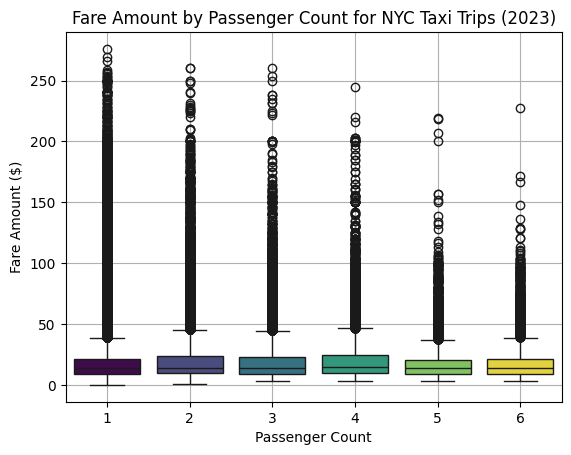

Correlation between passenger count and fare amount: 0.04
There is almost no correlation between passenger count and fare amount,
indicating fare is not significantly affected by number of passengers
(consistent with flat rates for extra passengers in NYC taxis).


In [95]:
# Show relationship between fare and number of passengers
sns.boxplot(x='passenger_count', y='fare_amount', data=df_nz,
            palette='viridis', hue='passenger_count', legend=False)
plt.title('Fare Amount by Passenger Count for NYC Taxi Trips (2023)')
plt.xlabel('Passenger Count')
plt.ylabel('Fare Amount ($)')
plt.grid(True)
plt.show()

corr = df_nz['passenger_count'].corr(df_nz['fare_amount'])
print(f"Correlation between passenger count and fare amount: {corr:.2f}")
print("There is almost no correlation between passenger count and fare amount,\nindicating fare is not significantly affected by number of passengers\n(consistent with flat rates for extra passengers in NYC taxis).")


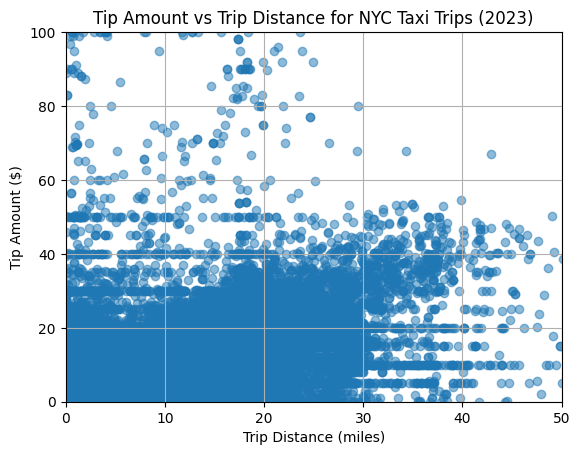

Correlation between trip distance and tip amount: 0.80
There is a positive correlation indicating that longer trips tend to receive higher tips, but with considerable variability.


In [99]:
# Show relationship between tip and trip distance
plt.scatter(df_nz['trip_distance'], df_nz['tip_amount'], alpha=0.5)
plt.title('Tip Amount vs Trip Distance for NYC Taxi Trips (2023)')
plt.xlabel('Trip Distance (miles)')
plt.ylabel('Tip Amount ($)')
plt.xlim(0, 50)  # Focus on trips up to 50 miles
plt.ylim(0, 100) # Focus on tips up to $100
plt.grid(True)
plt.show()

corr = df_nz['trip_distance'].corr(df_nz['tip_amount'])
print(f"Correlation between trip distance and tip amount: {corr:.2f}")
print("There is a positive correlation indicating that longer trips tend to receive higher tips, but with considerable variability.")


**3.1.8** <font color = red>[3 marks]</font> <br>
Analyse the distribution of different payment types (`payment_type`)

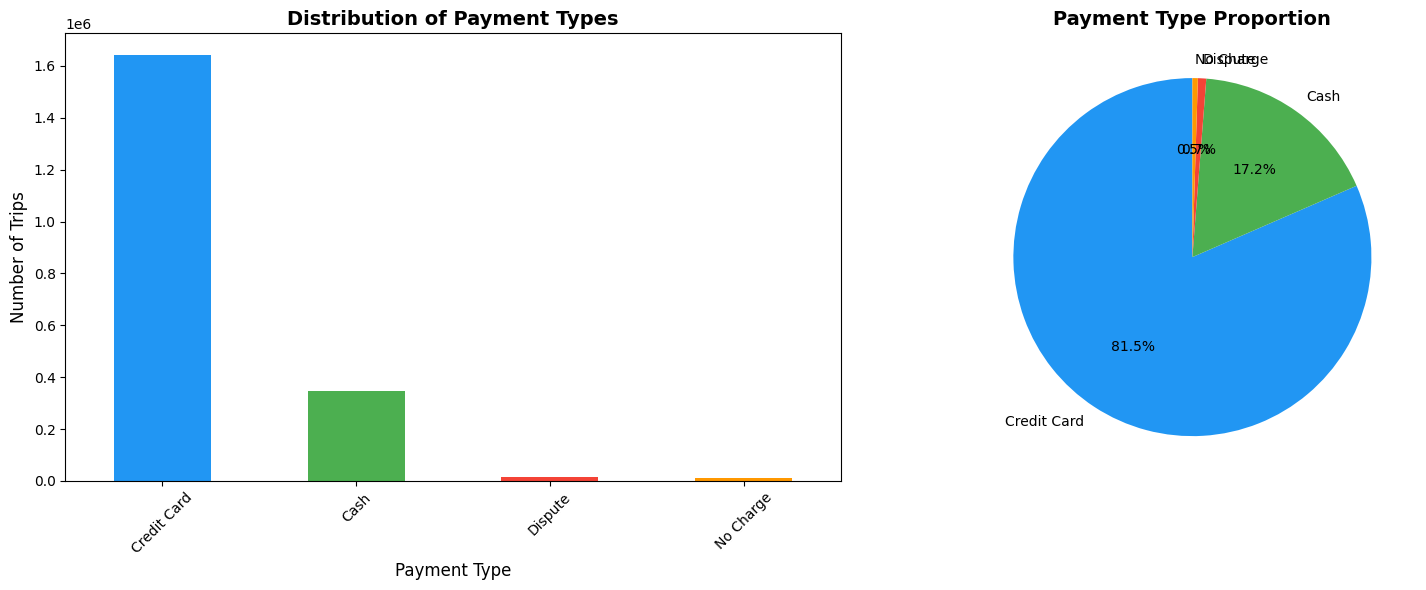


Payment Type Distribution:
  Credit Card: 1,643,483 (81.5%)
  Cash: 347,489 (17.2%)
  Dispute: 15,116 (0.7%)
  No Charge: 9,849 (0.5%)


In [109]:
# Analyse the distribution of different payment types (payment_type).
payment_labels = {1: 'Credit Card', 2: 'Cash', 3: 'No Charge', 4: 'Dispute', 5: 'Unknown', 6: 'Voided'}
payment_dist = df['payment_type'].map(payment_labels).value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
payment_colors = {
    'Credit Card': '#2196F3',  # blue
    'Cash':        '#4CAF50',  # green
    'No Charge':   '#FF9800',  # orange
    'Dispute':     '#F44336',  # red
    'Unknown':     '#9C27B0',  # purple
    'Voided':      '#607D8B'   # grey
}
colors = [payment_colors[label] for label in payment_dist.index]

# Bar chart
payment_dist.plot(kind='bar', ax=axes[0], color=colors)
axes[0].set_title('Distribution of Payment Types', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Payment Type', fontsize=12)
axes[0].set_ylabel('Number of Trips', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

# Pie chart
axes[1].pie(payment_dist.values, labels=payment_dist.index, autopct='%1.1f%%', startangle=90,
           colors=colors)
axes[1].set_title('Payment Type Proportion', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nPayment Type Distribution:")
for ptype, count in payment_dist.items():
    print(f"  {ptype}: {count:,} ({count/len(df)*100:.1f}%)")

- 1= Credit card
- 2= Cash
- 3= No charge
- 4= Dispute



##### Geographical Analysis

For this, you have to use the *taxi_zones.shp* file from the *taxi_zones* folder.

There would be multiple files inside the folder (such as *.shx, .sbx, .sbn* etc). You do not need to import/read any of the files other than the shapefile, *taxi_zones.shp*.

Do not change any folder structure - all the files need to be present inside the folder for it to work.

The folder structure should look like this:
```
Taxi Zones
|- taxi_zones.shp.xml
|- taxi_zones.prj
|- taxi_zones.sbn
|- taxi_zones.shp
|- taxi_zones.dbf
|- taxi_zones.shx
|- taxi_zones.sbx

 ```

 You only need to read the `taxi_zones.shp` file. The *shp* file will utilise the other files by itself.

We will use the *GeoPandas* library for geopgraphical analysis
```
import geopandas as gpd
```

More about geopandas and shapefiles: [About](https://geopandas.org/en/stable/about.html)


Reading the shapefile is very similar to *Pandas*. Use `gpd.read_file()` function to load the data (*taxi_zones.shp*) as a GeoDataFrame. Documentation: [Reading and Writing Files](https://geopandas.org/en/stable/docs/user_guide/io.html)

In [ ]:
# !pip install geopandas

**3.1.9** <font color = red>[2 marks]</font> <br>
Load the shapefile and display it.

In [ ]:
# import geopandas as gpd


# Read the shapefile using geopandas
zones = # read the .shp file using gpd
zones.head()

Now, if you look at the DataFrame created, you will see columns like: `OBJECTID`,`Shape_Leng`, `Shape_Area`, `zone`, `LocationID`, `borough`, `geometry`.
<br><br>

Now, the `locationID` here is also what we are using to mark pickup and drop zones in the trip records.

The geometric parameters like shape length, shape area and geometry are used to plot the zones on a map.

This can be easily done using the `plot()` method.

In [ ]:
# print(zones.info())
# zones.plot()

Now, you have to merge the trip records and zones data using the location IDs.



**3.1.10** <font color = red>[3 marks]</font> <br>
Merge the zones data into trip data using the `locationID` and `PULocationID` columns.

In [ ]:
# Merge zones and trip records using locationID and PULocationID



**3.1.11** <font color = red>[3 marks]</font> <br>
Group data by location IDs to find the total number of trips per location ID

In [ ]:
# Group data by location and calculate the number of trips



**3.1.12** <font color = red>[2 marks]</font> <br>
Now, use the grouped data to add number of trips to the GeoDataFrame.

We will use this to plot a map of zones showing total trips per zone.

In [ ]:
# Merge trip counts back to the zones GeoDataFrame




The next step is creating a color map (choropleth map) showing zones by the number of trips taken.

Again, you can use the `zones.plot()` method for this. [Plot Method GPD](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.plot.html#geopandas.GeoDataFrame.plot)

But first, you need to define the figure and axis for the plot.

`fig, ax = plt.subplots(1, 1, figsize = (12, 10))`

This function creates a figure (fig) and a single subplot (ax)

---

After setting up the figure and axis, we can proceed to plot the GeoDataFrame on this axis. This is done in the next step where we use the plot method of the GeoDataFrame.

You can define the following parameters in the `zones.plot()` method:
```
column = '',
ax = ax,
legend = True,
legend_kwds = {'label': "label", 'orientation': "<horizontal/vertical>"}
```

To display the plot, use `plt.show()`.

**3.1.13** <font color = red>[3 marks]</font> <br>
Plot a color-coded map showing zone-wise trips

In [ ]:
# Define figure and axis


# Plot the map and display it



In [ ]:
# can you try displaying the zones DF sorted by the number of trips?



Here we have completed the temporal, financial and geographical analysis on the trip records.

**Compile your findings from general analysis below:**

You can consider the following points:

* Busiest hours, days and months
* Trends in revenue collected
* Trends in quarterly revenue
* How fare depends on trip distance, trip duration and passenger counts
* How tip amount depends on trip distance
* Busiest zones


#### **3.2** Detailed EDA: Insights and Strategies
<font color = red>[50 marks]</font> <br>

Having performed basic analyses for finding trends and patterns, we will now move on to some detailed analysis focussed on operational efficiency, pricing strategies, and customer experience.

##### Operational Efficiency

Analyze variations by time of day and location to identify bottlenecks or inefficiencies in routes

**3.2.1** <font color = red>[3 marks]</font> <br>
Identify slow routes by calculating the average time taken by cabs to get from one zone to another at different hours of the day.

Speed on a route *X* for hour *Y* = (*distance of the route X / average trip duration for hour Y*)

In [ ]:
# Find routes which have the slowest speeds at different times of the day



How does identifying high-traffic, high-demand routes help us?

**3.2.2** <font color = red>[3 marks]</font> <br>
Calculate the number of trips at each hour of the day and visualise them. Find the busiest hour and show the number of trips for that hour.

In [ ]:
# Visualise the number of trips per hour and find the busiest hour



Remember, we took a fraction of trips. To find the actual number, you have to scale the number up by the sampling ratio.

**3.2.3** <font color = red>[2 mark]</font> <br>
Find the actual number of trips in the five busiest hours

In [ ]:
# Scale up the number of trips

# Fill in the value of your sampling fraction and use that to scale up the numbers
sample_fraction =



**3.2.4** <font color = red>[3 marks]</font> <br>
Compare hourly traffic pattern on weekdays. Also compare for weekend.

In [ ]:
# Compare traffic trends for the week days and weekends



What can you infer from the above patterns? How will finding busy and quiet hours for each day help us?

**3.2.5** <font color = red>[3 marks]</font> <br>
Identify top 10 zones with high hourly pickups. Do the same for hourly dropoffs. Show pickup and dropoff trends in these zones.

In [ ]:
# Find top 10 pickup and dropoff zones



**3.2.6** <font color = red>[3 marks]</font> <br>
Find the ratio of pickups and dropoffs in each zone. Display the 10 highest (pickup/drop) and 10 lowest (pickup/drop) ratios.

In [ ]:
# Find the top 10 and bottom 10 pickup/dropoff ratios



**3.2.7** <font color = red>[3 marks]</font> <br>
Identify zones with high pickup and dropoff traffic during night hours (11PM to 5AM)

In [ ]:
# During night hours (11pm to 5am) find the top 10 pickup and dropoff zones
# Note that the top zones should be of night hours and not the overall top zones



Now, let us find the revenue share for the night time hours and the day time hours. After this, we will move to deciding a pricing strategy.

**3.2.8** <font color = red>[2 marks]</font> <br>
Find the revenue share for nighttime and daytime hours.

In [ ]:
# Filter for night hours (11 PM to 5 AM)



##### Pricing Strategy

**3.2.9** <font color = red>[2 marks]</font> <br>
For the different passenger counts, find the average fare per mile per passenger.

For instance, suppose the average fare per mile for trips with 3 passengers is 3 USD/mile, then the fare per mile per passenger will be 1 USD/mile.

In [ ]:
# Analyse the fare per mile per passenger for different passenger counts




**3.2.10** <font color = red>[3 marks]</font> <br>
Find the average fare per mile by hours of the day and by days of the week

In [ ]:
# Compare the average fare per mile for different days and for different times of the day



**3.2.11** <font color = red>[3 marks]</font> <br>
Analyse the average fare per mile for the different vendors for different hours of the day

In [ ]:
# Compare fare per mile for different vendors



**3.2.12** <font color = red>[5 marks]</font> <br>
Compare the fare rates of the different vendors in a tiered fashion. Analyse the average fare per mile for distances upto 2 miles. Analyse the fare per mile for distances from 2 to 5 miles. And then for distances more than 5 miles.


In [ ]:
# Defining distance tiers



##### Customer Experience and Other Factors

**3.2.13** <font color = red>[5 marks]</font> <br>
Analyse average tip percentages based on trip distances, passenger counts and time of pickup. What factors lead to low tip percentages?

In [ ]:
#  Analyze tip percentages based on distances, passenger counts and pickup times



Additional analysis [optional]: Let's try comparing cases of low tips with cases of high tips to find out if we find a clear aspect that drives up the tipping behaviours

In [ ]:
# Compare trips with tip percentage < 10% to trips with tip percentage > 25%



**3.2.14** <font color = red>[3 marks]</font> <br>
Analyse the variation of passenger count across hours and days of the week.

In [ ]:
# See how passenger count varies across hours and days




**3.2.15** <font color = red>[2 marks]</font> <br>
Analyse the variation of passenger counts across zones

In [ ]:
# How does passenger count vary across zones



In [ ]:
# For a more detailed analysis, we can use the zones_with_trips GeoDataFrame
# Create a new column for the average passenger count in each zone.



Find out how often surcharges/extra charges are applied to understand their prevalance

**3.2.16** <font color = red>[5 marks]</font> <br>
Analyse the pickup/dropoff zones or times when extra charges are applied more frequently

In [ ]:
# How often is each surcharge applied?



## **4** Conclusion
<font color = red>[15 marks]</font> <br>

### **4.1** Final Insights and Recommendations
<font color = red>[15 marks]</font> <br>

Conclude your analyses here. Include all the outcomes you found based on the analysis.

Based on the insights, frame a concluding story explaining suitable parameters such as location, time of the day, day of the week etc. to be kept in mind while devising a strategy to meet customer demand and optimise supply.

**4.1.1** <font color = red>[5 marks]</font> <br>
Recommendations to optimize routing and dispatching based on demand patterns and operational inefficiencies

**4.1.2** <font color = red>[5 marks]</font> <br>

Suggestions on strategically positioning cabs across different zones to make best use of insights uncovered by analysing trip trends across time, days and months.

**4.1.3** <font color = red>[5 marks]</font> <br>
Propose data-driven adjustments to the pricing strategy to maximize revenue while maintaining competitive rates with other vendors.